# Pixel Art PFP Generator — data pipeline, training, export

Companion notebook to `../docs/PIXEL_ART_GENERATION_PLAN.md`. Sections:

0. Validate CUDA
1. Environment & **style config** (`STYLE`, `RUN_NAME`, vocab, prompts)
2. Generate source images (FLUX.1-schnell; txt2img, or img2img from the style references)
3. Pixelise + quantise to ≤9 palette indices
4. Dataset
5. Masked discrete diffusion transformer
6. Train (warm start from a previous run)
7. Sample & visualise
8. Export to ONNX

**v7 — "shaman" style.** Style is now a config switch. The green stone-head references in `pfp_data/new_ref/`
(16 images, white background) are the only material for this style, so source images are made by
**img2img from those references**: each generated image starts from a random reference (or its mirror), a
sampled strength, and a prompt that adds the attribute (figure / headgear / accessory / marking).
Background is a switch (`SHAMAN_BG`): index 0 is transparent on-chain either way, but the darkest jade
pebbles are near-black, so a black background loses face cells to index 0; white is the default and
`build_library.py --bg-mode white` matches it. Black (references swapped, prompt changed, black rule) is one flag away.

**Workflow for a new style**
1. Set `STYLE`, `RUN_NAME = "<style>_check"`, `N_IMAGES = 100` → run §2, §3 → look at the contact sheets.
   Tune `strength`, the prompt phrases and `bg_thresh` until the 64×64 grids look right.
2. Set `RUN_NAME = "<style>"`, `N_IMAGES = 3000+` → run §2, §3 again (a few hours at ~1.5 s/img).
3. §6: train, warm-started from `pfp_data/ckpt_64.pt` (the v6 model) so a few thousand images are enough.
4. Or skip training: per PLAN §14 the curated pool can be built straight from the generated grids with
   `pfp-library/tools/build_library.py --raw pfp_data/<run>/raw --labels pfp_data/<run>/labels.jsonl --vocab pfp_data/<run>/vocab.json`.

Every run writes to `pfp_data/<RUN_NAME>/` (raw/, labels.jsonl, vocab.json, grids_64.npy, labels.npy, ckpt_64.pt)
so runs never overwrite each other. The v6 files at `pfp_data/` root are untouched.

## 0. Validate CUDA before running anything

Run the two cells below first. Do not proceed to section 2 until every check passes.

**What "pass" looks like**
- `torch.cuda.is_available()` → `True`
- `torch.version.cuda` shows a version (e.g. `12.4`), not `None`
- Your card name and VRAM are printed
- The matmul test finishes in well under a second and prints a device of `cuda:0`
- `bf16 supported` → `True` on Ampere (RTX 30xx) or newer; `False` is fine, the notebook falls back to fp16

**If `is_available()` is `False`**
1. Check the driver: run `nvidia-smi` in a terminal. If it errors, install/update the NVIDIA driver first.
2. Check the torch build: `torch.version.cuda` being `None` means you have the CPU-only wheel. Reinstall with the CUDA wheel from https://pytorch.org/get-started/locally/ (pick the CUDA version ≤ the "CUDA Version" shown by `nvidia-smi`), e.g.
   `pip install --force-reinstall torch torchvision --index-url https://download.pytorch.org/whl/cu124`
3. Check the kernel: in VS Code, confirm the notebook kernel (top right) is the same environment you installed torch into. Restart the kernel after reinstalling.

**VRAM guidance (from the printed figure)**
- ≥ 24 GB: comment out `pipe.enable_model_cpu_offload()` in section 2 for faster generation.
- 12–24 GB: leave CPU offload on (default).
- < 12 GB: FLUX may still fail even with offload; set `USE_SD_TURBO = True` in section 2. Also lower `batch` in `CONFIGS` for the 64px model.


In [1]:
# 0a. Driver / toolkit view (runs the CLI; safe to skip if it errors, but then fix the driver)
!nvidia-smi


Sun Sep 20 20:30:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.57                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4080 ...    On  |   00000000:01:00.0  On |                  N/A |
|  0%   38C    P8             19W /  320W |    3854MiB /  16376MiB |     27%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# 0b. PyTorch CUDA checks — must all pass
import torch, time
print("torch version      :", torch.__version__)
print("torch CUDA build   :", torch.version.cuda)          # None => CPU-only wheel installed
print("cuda available     :", torch.cuda.is_available())
assert torch.cuda.is_available(), "CUDA not available to PyTorch - see instructions above"

p = torch.cuda.get_device_properties(0)
print("device             :", p.name)
print("VRAM               :", f"{p.total_memory/1e9:.1f} GB")
print("compute capability :", f"{p.major}.{p.minor}")
print("bf16 supported     :", torch.cuda.is_bf16_supported())
print("cuDNN version      :", torch.backends.cudnn.version())

# real work on the GPU, timed
x = torch.randn(4096, 4096, device="cuda")
torch.cuda.synchronize(); t = time.time()
y = x @ x
torch.cuda.synchronize()
print("4096x4096 matmul   :", f"{(time.time()-t)*1000:.1f} ms on", y.device)
assert str(y.device).startswith("cuda"), "tensor did not land on the GPU"

# fused attention kernels (needed for the 64px model at 4k tokens)
from torch.nn.attention import sdpa_kernel, SDPBackend
q = torch.randn(1, 8, 4096, 48, device="cuda", dtype=torch.float16)
ok = {}
for name, be in [("flash", SDPBackend.FLASH_ATTENTION), ("mem_efficient", SDPBackend.EFFICIENT_ATTENTION)]:
    try:
        with sdpa_kernel(be):
            torch.nn.functional.scaled_dot_product_attention(q, q, q)
        ok[name] = True
    except Exception as e:
        ok[name] = False
print("fused SDPA backends:", ok, "(at least one True is needed for the 64px config)")
print("\nALL CUDA CHECKS PASSED")


torch version      : 2.14.0+cu130
torch CUDA build   : 13.0
cuda available     : True
device             : NVIDIA GeForce RTX 4080 SUPER
VRAM               : 17.2 GB
compute capability : 8.9
bf16 supported     : True
cuDNN version      : 92400
4096x4096 matmul   : 74.1 ms on cuda:0
fused SDPA backends: {'flash': True, 'mem_efficient': True} (at least one True is needed for the 64px config)

ALL CUDA CHECKS PASSED


In [ ]:
# 1. Environment
# pip install torch torchvision diffusers transformers accelerate pillow numpy scikit-learn matplotlib onnx onnxruntime
import os, json, math, random, time, hashlib
from pathlib import Path
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display

print(torch.__version__, torch.cuda.is_available())
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(p.name, f"{p.total_memory/1e9:.1f} GB VRAM")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


2.14.0+cu130 True
NVIDIA GeForce RTX 4080 SUPER 17.2 GB VRAM


: 

In [ ]:
# 1b. Config — pick the style and the run
ROOT = Path("../pfp_data"); ROOT.mkdir(exist_ok=True)

STYLE       = "shaman"            # "shaman" (green stone heads from new_ref/) | "photo" (v6 realistic portraits)
RUN_NAME    = "v7_shaman_check"   # 100-image aesthetic check; then e.g. "v7_shaman" for the full run
N_IMAGES    = 100                 # check batch; 3000-5000 for the real run
GEN_RES     = 512
GEN_BATCH   = 2
GRID_SIZES  = [64]                # FOREST is G=64; add 32 back if wanted
MAX_COLOURS = 9                   # non-background indices; index 0 = background
MIN_FG_FRAC = 0.10                # reject images with less foreground than this
SEED        = 1234

RUN_DIR  = ROOT / RUN_NAME; RUN_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR  = RUN_DIR / "raw";  RAW_DIR.mkdir(exist_ok=True)
meta_path = RUN_DIR / "labels.jsonl"

# ---- shaman: attribute vocab + the phrase each value contributes to the prompt (None = omitted) ----
SHAMAN_PHRASES = {
    "figure":    {"male":   "male figure with a broad square jaw",
                  "female": "female figure with a softer oval face"},
    "headgear":  {"none": None,
                  "antlers":  "with branching antlers growing from the top of the head",
                  "crown":    "wearing a carved stone crown with crystal points",
                  "horns":    "with two curved horns",
                  "headband": "wearing a carved stone headband",
                  "hood":     "wearing a hood draped over the head",
                  "turban":   "wearing a wrapped turban",
                  "braids":   "with long braided hair falling to the shoulders",
                  "bun":      "with hair gathered in a high bun"},
    "accessory": {"none": None,
                  "nose ring":    "with a gold nose ring",
                  "big earrings": "with big round hoop earrings",
                  "glasses":      "wearing round glasses",
                  "sunglasses":   "wearing dark sunglasses",
                  "pipe":         "smoking a long carved pipe held in the mouth",
                  "necklace":     "wearing a beaded stone necklace",
                  "flower":       "with a flower tucked behind one ear"},
    "marking":   {"none": None,
                  "beard":      "with a striped beard of gold stones",
                  "moustache":  "with a moustache of gold stones",
                  "crescent":   "with a gold crescent moon on the forehead",
                  "stripes":    "with gold stripes on the cheeks",
                  "third eye":  "with a single gold stone on the forehead",
                  "chin lines": "with vertical gold lines on the chin"},
}
SHAMAN_STYLE = ("monumental carved stone head sculpture, head and shoulders, front-facing, symmetrical, centered, "
                "entire surface a mosaic of small polished green jade pebbles, a few gold-yellow stones forming "
                "lines and accents, serene expression, closed eyes, long flat nose, straight mouth")
# Background colour of the generated images. Index 0 is transparent on-chain either way, so this only decides
# how reliably the quantiser can separate background from face:
#   "white" (default): references are used as-is, prompt asks for white; bg = min(R,G,B) > 255-thresh.
#            Nothing in the face is near-white, so no face cells are lost.
#   "black": references are swapped white->black first, prompt asks for black; bg = max(R,G,B) < thresh.
#            The darkest jade pebbles are near-black (~2,18,13): on the references this rule turns about a
#            quarter of the face into index 0 at thresh 40 (holes in the silhouette). Thresh 12 recovers it on
#            the references, but generated black backgrounds are not reliably that clean. Compare 3a with 3c.
SHAMAN_BG    = "white"
SHAMAN_END   = ("isolated on a plain %s background, soft studio lighting, sharp focus, high detail, no text"
                % ("solid black" if SHAMAN_BG == "black" else "pure white"))

# ---- photo (v6) kept so the old runs stay reproducible ----
PHOTO_VOCAB = {
    "hair":       ["short", "long", "curly", "bald", "mohawk", "ponytail", "afro", "bob"],
    "headwear":   ["none", "cap", "beanie", "crown", "hood", "helmet", "headband", "top hat"],
    "accessory":  ["none", "glasses", "sunglasses", "earring", "headphones", "eyepatch", "scarf", "mask"],
    "expression": ["neutral", "smiling", "frowning", "surprised", "angry", "winking"],
}
HAIR_COLOURS  = ["bright pink", "electric blue", "vivid purple", "neon green", "bright orange",
                 "platinum blonde", "ginger red", "turquoise", "lilac", "golden blonde"]
CLOTH_COLOURS = ["bright red", "yellow", "white", "orange", "hot pink", "sky blue",
                 "lime green", "cream", "coral", "light grey"]
HAT_COLOURS   = ["red", "yellow", "white", "orange", "bright blue", "pink", "lime green"]

STYLES = {
    "shaman": dict(
        vocab     = {a: list(d) for a, d in SHAMAN_PHRASES.items()},
        gen_mode  = "img2img",           # "img2img": start from a random reference | "txt2img": prompt only
        ref_dir   = ROOT / "new_ref",    # style references (white background originals)
        ref_swap_bg = SHAMAN_BG == "black",   # swap white -> black on the references before they are used as init images
        strength  = (0.72, 0.92),        # img2img strength range sampled per batch; higher = more variety, less reference
        bg_mode   = SHAMAN_BG,           # quantiser background rule: black = max(R,G,B) < thresh; white = min(R,G,B) > 255-thresh
        bg_thresh = 40 if SHAMAN_BG == "white" else 12,
    ),
    "photo": dict(vocab=PHOTO_VOCAB, gen_mode="txt2img", ref_dir=None, ref_swap_bg=False, strength=None,
                  bg_mode="black", bg_thresh=40),
}
S = STYLES[STYLE]
VOCAB = S["vocab"]; ATTRS = list(VOCAB); ATTR_SIZES = [len(VOCAB[a]) for a in ATTRS]
json.dump(VOCAB, open(RUN_DIR / "vocab.json", "w"), indent=2)

def build_prompt(lab):
    if STYLE == "shaman":
        parts = [SHAMAN_STYLE] + [SHAMAN_PHRASES[a][lab[a]] for a in ATTRS if SHAMAN_PHRASES[a][lab[a]]] + [SHAMAN_END]
        return ", ".join(parts)
    parts = ["close-up studio portrait photograph of one person, head and shoulders, "
             "face filling the frame, centered, looking directly at the camera"]
    parts.append("bald head" if lab["hair"] == "bald" else f"{lab['hair_colour']} {lab['hair']} hair")
    if lab["headwear"]  != "none": parts.append(f"wearing a {lab['hat_colour']} {lab['headwear']}")
    if lab["accessory"] != "none": parts.append(f"wearing {lab['accessory']}")
    parts += [f"{lab['expression']} expression", f"wearing a {lab['cloth_colour']} top",
              "photorealistic, realistic skin texture, bright key light on the face with soft shadows, "
              "strong rim light outlining the head and shoulders, high contrast against a solid black background, "
              "85mm lens, sharp focus"]
    return ", ".join(parts)

def build_clip_prompt(lab):      # short prompt for the CLIP encoder (77-token budget)
    if STYLE == "shaman":
        extras = [lab[a] for a in ATTRS[1:] if lab[a] != "none"]
        return ", ".join(["green jade pebble mosaic stone head sculpture", lab["figure"]] + extras + [f"{SHAMAN_BG} background"])
    hair = "bald head" if lab["hair"] == "bald" else f"{lab['hair_colour']} hair"
    return f"close-up photo portrait, {hair}, {lab['cloth_colour']} top, rim light, solid black background, photorealistic"

random.seed(SEED)
labels = [{a: random.choice(VOCAB[a]) for a in ATTRS} for _ in range(N_IMAGES)]
if STYLE == "photo":
    for lab in labels:
        lab.update(hair_colour=random.choice(HAIR_COLOURS), cloth_colour=random.choice(CLOTH_COLOURS),
                   hat_colour=random.choice(HAT_COLOURS))
print(RUN_DIR, "| attrs", ATTR_SIZES)
print(build_prompt(labels[0])); print(build_clip_prompt(labels[0]))

../pfp_data/v7_shaman_check | attrs [2, 9, 8, 7]
monumental carved stone head sculpture, head and shoulders, front-facing, symmetrical, centered, entire surface a mosaic of small polished green jade pebbles, a few gold-yellow stones forming lines and accents, serene expression, closed eyes, long flat nose, straight mouth, female figure with a softer oval face, with branching antlers growing from the top of the head, isolated on a plain pure white background, soft studio lighting, sharp focus, high detail, no text
green jade pebble mosaic stone head sculpture, female, antlers, white background


## 2. Generate source images

FLUX.1-schnell, pre-quantised NF4 copy in `pfp_data/flux_schnell_nf4` (created on first run).

- `gen_mode = "img2img"` (shaman default): each image starts from a random style reference (or its mirror),
  denoised from `strength ∈ S["strength"]` with the attribute prompt. Schnell only has 4 steps, so
  `num_inference_steps` is raised to keep ≥ 4 *effective* steps at the sampled strength.
  Low strength ≈ the reference with small changes; high strength ≈ prompt-driven with the reference's colours/composition.
- `gen_mode = "txt2img"`: prompt only. Try it on a check batch too — if the style prompt alone holds, it gives far more variety.
- Resumable: files already listed in `labels.jsonl` are skipped.

/home/elsabella/forest/fenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/elsabella/forest/fenv/lib/python3.10/site-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
Loading pipeline components...: 100%|██████████| 7/7 [00:11<00:00,  1.69s/it]


32 reference images (incl. mirrors)


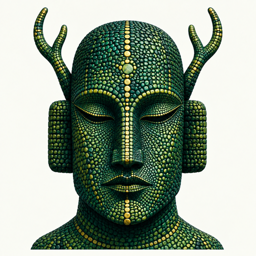

20 images, 1.62 s/img, 20:32:03
40 images, 1.53 s/img, 20:32:32
60 images, 1.48 s/img, 20:33:00
80 images, 1.45 s/img, 20:33:27
100 images, 1.43 s/img, 20:33:54
done -> ../pfp_data/v7_shaman_check/raw


In [5]:
from dotenv import load_dotenv
load_dotenv("../../.env")   # loads forest/.env (this notebook runs from forest/pixelart/notebooks/)
assert os.environ.get("HF_TOKEN"), "HF_TOKEN not found - check .env location and variable name"

import gc
if "pipe" in globals():
    del pipe
    gc.collect(); torch.cuda.empty_cache()

from diffusers import FluxPipeline, FluxImg2ImgPipeline
NF4_DIR = ROOT / "flux_schnell_nf4"
if not NF4_DIR.exists():                                            # first time: quantise, then save
    from diffusers.quantizers import PipelineQuantizationConfig
    quant = PipelineQuantizationConfig(
        quant_backend="bitsandbytes_4bit",
        quant_kwargs={"load_in_4bit": True, "bnb_4bit_quant_type": "nf4",
                      "bnb_4bit_compute_dtype": torch.bfloat16},
        components_to_quantize=["transformer", "text_encoder_2"],
    )
    FluxPipeline.from_pretrained("black-forest-labs/FLUX.1-schnell", quantization_config=quant,
                                 torch_dtype=torch.bfloat16).save_pretrained(NF4_DIR)

PipeCls = FluxImg2ImgPipeline if S["gen_mode"] == "img2img" else FluxPipeline
pipe = PipeCls.from_pretrained(NF4_DIR, torch_dtype=torch.bfloat16).to(DEVICE)
pipe.set_progress_bar_config(disable=True)
gen_kwargs = dict(guidance_scale=0.0, max_sequence_length=256, height=GEN_RES, width=GEN_RES)

def swap_bg_to_black(im, lo=200, hi=245):
    """White background -> black with a soft edge: pixels whose min(R,G,B) rises from lo to hi fade to black."""
    a = np.asarray(im.convert("RGB")).astype(np.float32)
    t = np.clip((a.min(axis=2, keepdims=True) - lo) / (hi - lo), 0, 1)
    return Image.fromarray((a * (1 - t)).astype(np.uint8))

refs = []                                                           # (name, flipped, PIL image at GEN_RES)
if S["gen_mode"] == "img2img":
    for p in sorted(S["ref_dir"].glob("*.png")):
        im = Image.open(p).convert("RGB"); w, h = im.size; s = min(w, h)
        im = im.crop(((w-s)//2, (h-s)//2, (w-s)//2+s, (h-s)//2+s)).resize((GEN_RES, GEN_RES), Image.LANCZOS)
        if S["ref_swap_bg"]: im = swap_bg_to_black(im)
        refs.append((p.name, False, im))
        refs.append((p.name, True, im.transpose(Image.FLIP_LEFT_RIGHT)))
    assert refs, f"no references in {S['ref_dir']}"
    print(len(refs), "reference images (incl. mirrors)")
    display(refs[0][2].resize((256, 256)))

done = set()
if meta_path.exists():
    done = {json.loads(l)["file"] for l in open(meta_path)}

rng = random.Random(SEED)
t0 = time.time(); n_done = 0
with open(meta_path, "a") as f:
    for start in range(0, N_IMAGES, GEN_BATCH):
        idxs = [i for i in range(start, min(start+GEN_BATCH, N_IMAGES)) if f"{i:06d}.png" not in done]
        if not idxs: continue
        prompts      = [build_prompt(labels[i]) for i in idxs]
        clip_prompts = [build_clip_prompt(labels[i]) for i in idxs]
        g = [torch.Generator(DEVICE).manual_seed(SEED + i) for i in idxs]
        extra = {}
        if S["gen_mode"] == "img2img":
            picks = [refs[hashlib.sha256(f"{SEED}:{i}".encode()).digest()[0] % len(refs)] for i in idxs]
            strength = rng.uniform(*S["strength"])
            extra = dict(image=[p[2] for p in picks], strength=strength,
                         num_inference_steps=max(4, math.ceil(4 / strength)))
        else:
            extra = dict(num_inference_steps=4)
        imgs = pipe(prompt=clip_prompts, prompt_2=prompts, generator=g, **gen_kwargs, **extra).images
        for j, (i, im) in enumerate(zip(idxs, imgs)):
            fn = f"{i:06d}.png"
            im.save(RAW_DIR / fn)
            rec = {"file": fn, **labels[i]}
            if S["gen_mode"] == "img2img":
                rec.update(ref=picks[j][0], flip=picks[j][1], strength=round(strength, 3))
            f.write(json.dumps(rec) + "\n")
        n_done += len(idxs)
        if n_done % 20 < GEN_BATCH:
            print(f"{n_done} images, {(time.time()-t0)/n_done:.2f} s/img, {time.strftime('%H:%M:%S')}")
print("done ->", RAW_DIR)

In [ ]:
# 2b. Contact sheet of the raw generations (check batch): does the style hold? do the attributes show?
recs = [json.loads(l) for l in open(meta_path)]
def raw_sheet(recs, n=40, ncol=8, thumb=160):
    recs = recs[:n]; nrow = math.ceil(len(recs) / ncol)
    sheet = Image.new("RGB", (ncol*thumb, nrow*thumb), (20, 20, 20))
    for k, r in enumerate(recs):
        sheet.paste(Image.open(RAW_DIR / r["file"]).resize((thumb, thumb)), ((k % ncol)*thumb, (k // ncol)*thumb))
    return sheet
display(raw_sheet(recs))
for r in recs[:8]: print({k: r[k] for k in r if k != "file"})

## 3. Pixelise + quantise

Both grid sizes from each source image. Background → 0 by `S["bg_mode"]` (black: `max(R,G,B) < thresh`;
white: `min(R,G,B) > 255-thresh`). Foreground → k-means (k ≤ 9) → clusters sorted dark→light → indices 1..k.
Same contract as `pfp-library/js/quantise.js` / `build_library.py` (those use luminance buckets instead of k-means;
for the near-monochrome shaman style the two agree closely).

In [6]:
from sklearn.cluster import KMeans

def luminance(rgb):  # rgb: (...,3) float 0-255
    return 0.299*rgb[...,0] + 0.587*rgb[...,1] + 0.114*rgb[...,2]

def bg_mask(px, mode=None, thresh=None):
    mode = mode or S["bg_mode"]; thresh = S["bg_thresh"] if thresh is None else thresh
    if mode == "black": return px.max(axis=1) < thresh
    if mode == "white": return px.min(axis=1) > 255 - thresh
    raise ValueError(mode)

def quantise(img_rgb, max_colours=MAX_COLOURS, bg_mode=None, bg_thresh=None, seed=0, return_centres=False):
    """img_rgb: (H,W,3) uint8 -> (H,W) uint8 index grid, or None if rejected."""
    px = img_rgb.reshape(-1, 3).astype(np.float32)
    bg = bg_mask(px, bg_mode, bg_thresh)
    fg = px[~bg]
    if len(fg) < MIN_FG_FRAC * len(px):
        return (None, None) if return_centres else None
    k = min(max_colours, len(np.unique(fg, axis=0)))
    km = KMeans(n_clusters=k, n_init=4, random_state=seed).fit(fg)
    order = np.argsort(luminance(km.cluster_centers_))          # dark -> light
    rank = np.empty(k, dtype=np.int64); rank[order] = np.arange(1, k+1)
    out = np.zeros(len(px), dtype=np.uint8)
    out[~bg] = rank[km.labels_]
    grid = out.reshape(img_rgb.shape[:2])
    return (grid, km.cluster_centers_[order]) if return_centres else grid

def pixelise(pil_img, size):
    w, h = pil_img.size; s = min(w, h)
    im = pil_img.crop(((w-s)//2, (h-s)//2, (w-s)//2+s, (h-s)//2+s))
    return np.asarray(im.resize((size, size), Image.BOX).convert("RGB"))

# preview palettes: index 0 = black (transparent on-chain); 1..9 dark -> light
DEMO_PALETTE = np.array([[0,0,0],[40,20,60],[90,40,90],[150,60,100],[200,90,90],
                         [230,140,80],[240,190,90],[250,230,140],[255,250,220],[255,255,255]], dtype=np.uint8)
JADE_PALETTE = np.array([[0,0,0],[2,18,13],[14,43,27],[30,65,39],[48,85,53],[70,100,63],
                         [95,120,78],[130,140,85],[155,168,140],[195,203,190]], dtype=np.uint8)  # mean k-means centres of new_ref
PALETTE = JADE_PALETTE if STYLE == "shaman" else DEMO_PALETTE

def show(grid_batch, ncol=8, palette=None):
    palette = PALETTE if palette is None else palette
    n = len(grid_batch); nrow = math.ceil(n/ncol)
    fig, ax = plt.subplots(nrow, ncol, figsize=(ncol*1.5, nrow*1.5))
    for i, a in enumerate(np.atleast_1d(ax).flat):
        a.axis("off")
        if i < n: a.imshow(palette[grid_batch[i]], interpolation="nearest")
    plt.show()

16 references; fg fraction 0.5


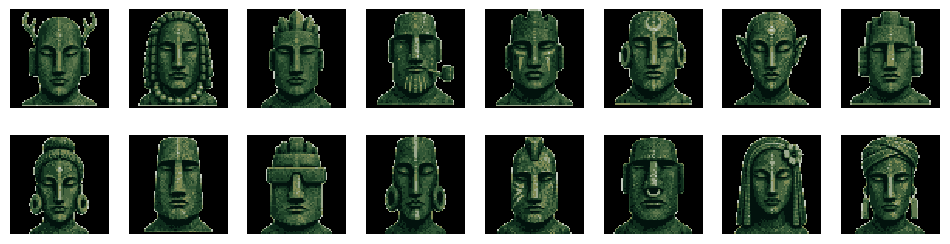

In [7]:
# 3a. Target check: the style references themselves through the quantiser (no GPU needed).
# This is what "right" looks like at 64x64 - compare the generated grids in 3c against it.
if S["ref_dir"]:
    ref_grids = []
    for p in sorted(S["ref_dir"].glob("*.png")):
        im = Image.open(p).convert("RGB")
        # references are the white-background originals: detect white directly (the black swap applies to init images)
        g = quantise(pixelise(im, 64), bg_mode="white", bg_thresh=40)
        if g is not None: ref_grids.append(g)
    print(len(ref_grids), "references; fg fraction", np.mean([(g > 0).mean() for g in ref_grids]).round(2))
    show(ref_grids, ncol=8)

In [8]:
# 3b. Build the grids for this run -> RUN_DIR/grids_<size>.npy, labels.npy
recs = [json.loads(l) for l in open(meta_path)]
grids = {s: [] for s in GRID_SIZES}; lab_ids = []; kept = 0; rejected = []
for r in recs:
    im = Image.open(RAW_DIR / r["file"])
    per_size = {s: quantise(pixelise(im, s)) for s in GRID_SIZES}
    if any(v is None for v in per_size.values()):
        rejected.append(r["file"]); continue
    for s in GRID_SIZES: grids[s].append(per_size[s])
    lab_ids.append([VOCAB[a].index(r[a]) for a in ATTRS]); kept += 1
for s in GRID_SIZES:
    np.save(RUN_DIR / f"grids_{s}.npy", np.stack(grids[s]))
np.save(RUN_DIR / "labels.npy", np.array(lab_ids, dtype=np.int64))
print(f"kept {kept}/{len(recs)}; rejected (too little foreground): {rejected[:10]}")

kept 100/100; rejected (too little foreground): []


64 (100, 64, 64) max index 9 fg fraction mean 0.47 min 0.30 max 0.71


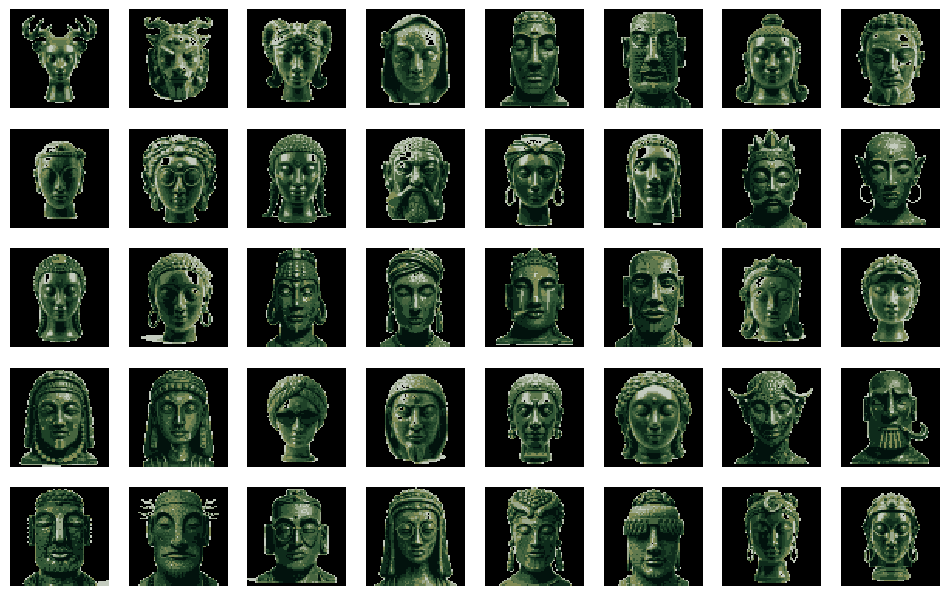

In [9]:
# 3c. Visual check of the generated grids (compare with 3a). Also: foreground fraction and colour count stats.
for s in GRID_SIZES:
    g = np.load(RUN_DIR / f"grids_{s}.npy"); print(s, g.shape, "max index", g.max(),
          "fg fraction mean %.2f min %.2f max %.2f" % ((g > 0).mean((1, 2)).mean(), (g > 0).mean((1, 2)).min(), (g > 0).mean((1, 2)).max()))
    show(g[:40])

## 4. Dataset

In [10]:
class GridDS(torch.utils.data.Dataset):
    """Index grids + attribute ids of one run. flip=True mirrors grids at random (faces are near-symmetric;
    doubles a small dataset for free)."""
    def __init__(self, size, run_dir=None, flip=True):
        run_dir = run_dir or RUN_DIR
        self.size = size; self.flip = flip
        self.g = torch.from_numpy(np.load(run_dir / f"grids_{size}.npy")).long()       # (N, S, S)
        self.y = torch.from_numpy(np.load(run_dir / "labels.npy")).long()               # (N, A)
        assert self.y.shape[1] == len(ATTRS), "labels.npy attribute count != current VOCAB - wrong run/style?"
    def __len__(self): return len(self.g)
    def __getitem__(self, i):
        g = self.g[i]
        if self.flip and random.random() < 0.5: g = g.flip(1)
        return g.flatten(), self.y[i]

## 5. Model — masked discrete diffusion transformer

Bidirectional encoder over `[A attribute tokens] + [grid² pixel tokens]`. Vocab = 10 pixel classes + MASK.
Each attribute has an extra *null* id for classifier-free guidance. `A` and the vocab sizes come from the
current `VOCAB`, so a style with a different vocab gets fresh attribute embeddings; everything else
(token/positional embeddings, transformer, head) is shape-compatible with the v6 checkpoint and can be warm-started.

In [ ]:
N_CLASSES = 10
MASK_ID   = N_CLASSES

class MaskedPixelTransformer(nn.Module):
    def __init__(self, grid, attr_sizes, dim=256, depth=8, heads=8, dropout=0.1):
        super().__init__()
        self.grid, self.L, self.A = grid, grid*grid, len(attr_sizes)
        self.tok = nn.Embedding(N_CLASSES+1, dim)
        self.pos = nn.Parameter(torch.randn(1, self.L, dim) * 0.02)
        self.attr_emb = nn.ModuleList([nn.Embedding(n+1, dim) for n in attr_sizes])  # +1 = null
        self.attr_null = torch.tensor(attr_sizes)                                    # null id per attr
        self.attr_pos = nn.Parameter(torch.randn(1, self.A, dim) * 0.02)
        layer = nn.TransformerEncoderLayer(dim, heads, dim*4, dropout=dropout, activation="gelu",
                                           batch_first=True, norm_first=True)
        self.enc = nn.TransformerEncoder(layer, depth, enable_nested_tensor=False)
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, N_CLASSES)

    def forward(self, tokens, attrs):
        # tokens (B,L) int64 in [0..MASK_ID]; attrs (B,A) int64 -> logits (B,L,N_CLASSES)
        a = torch.stack([e(attrs[:, i]) for i, e in enumerate(self.attr_emb)], 1) + self.attr_pos
        x = self.tok(tokens) + self.pos
        h = self.enc(torch.cat([a, x], 1))
        return self.head(self.norm(h[:, self.A:]))

CONFIGS = {
    32: dict(dim=256, depth=8,  heads=8,  batch=64, steps=20000),
    64: dict(dim=384, depth=12, heads=12, batch=16, steps=10000),
}
def make_model(size):
    c = CONFIGS[size]
    m = MaskedPixelTransformer(size, ATTR_SIZES, c["dim"], c["depth"], c["heads"])
    print(size, f"{sum(p.numel() for p in m.parameters())/1e6:.1f}M params")
    return m


## 6. Train

- `init_from=`: warm start — copies every tensor whose name **and shape** match (attribute embeddings are skipped
  when the vocab changed). Recommended for a new style: the v6 model already knows heads-and-shoulders at 64×64,
  so a few thousand new-style grids and ~4k steps at a lower lr (1e-4) should adapt it. Judge by §7 samples, not loss.
- `resume=`: continue an interrupted run of the *same* config (loads model + EMA, keeps the checkpoint path).
- Checkpoints go to `RUN_DIR/ckpt_<size>.pt`.

In [ ]:
def mask_schedule(u):           # cosine: fraction of tokens masked at "time" u in [0,1]
    return torch.cos(u * math.pi / 2)

def load_matching(model, path, skip_prefix=("attr_emb.",)):
    """Copy tensors from a checkpoint's 'model' state where name and shape match; report the rest.
    Attribute embeddings are always re-initialised: a same-sized vocab in another style means different words."""
    ck = torch.load(path, map_location=DEVICE)
    src = ck["model"]; dst = model.state_dict(); copied, skipped = [], []
    for k, v in dst.items():
        if k in src and src[k].shape == v.shape and not k.startswith(skip_prefix): dst[k] = src[k]; copied.append(k)
        else: skipped.append(k)
    model.load_state_dict(dst)
    print(f"warm start from {path}: copied {len(copied)} tensors, re-initialised {len(skipped)}: {skipped}")

def train(size, attr_drop=0.1, lr=3e-4, ema_decay=0.999, log_every=200, resume=None, init_from=None, run_dir=None):
    run_dir = run_dir or RUN_DIR
    cfg = CONFIGS[size]
    ds = GridDS(size, run_dir)
    dl = torch.utils.data.DataLoader(ds, batch_size=min(cfg["batch"], len(ds)), shuffle=True, drop_last=False, num_workers=2)
    model = make_model(size).to(DEVICE)
    if init_from is not None: load_matching(model, init_from)
    ema = make_model(size).to(DEVICE); ema.load_state_dict(model.state_dict()); ema.eval()
    for p in ema.parameters(): p.requires_grad_(False)
    if resume is not None:
        ck = torch.load(resume, map_location=DEVICE)
        model.load_state_dict(ck["model"]); ema.load_state_dict(ck["ema"])
        print(f"resumed from step {ck['step']}")
    opt = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.96), weight_decay=0.03)
    total = cfg["steps"]; warm = 500
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda s: min(1, s/warm) * 0.5*(1+math.cos(math.pi*min(s,total)/total)))
    scaler_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    null = torch.tensor(ATTR_SIZES, device=DEVICE)
    ckpt_path = run_dir / f"ckpt_{size}.pt"
    step = 0; t0 = time.time()
    print(f"{len(ds)} grids, {total} steps -> {ckpt_path}")
    while step < total:
        for g, y in dl:
            g, y = g.to(DEVICE), y.to(DEVICE)
            B, L = g.shape
            # mask
            u = torch.rand(B, device=DEVICE)
            n_mask = (mask_schedule(u) * L).clamp(min=1).long()
            scores = torch.rand(B, L, device=DEVICE)
            thresh = scores.sort(dim=1).values.gather(1, (n_mask-1).unsqueeze(1))
            m = scores <= thresh
            inp = g.masked_fill(m, MASK_ID)
            # attribute dropout for CFG
            drop = torch.rand(B, len(ATTRS), device=DEVICE) < attr_drop
            y_in = torch.where(drop, null.expand_as(y), y)
            with torch.autocast("cuda", dtype=scaler_dtype, enabled=(DEVICE=="cuda")):
                logits = model(inp, y_in)
                loss = F.cross_entropy(logits[m], g[m])
            opt.zero_grad(set_to_none=True); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step(); step += 1
            with torch.no_grad():
                for pe, pm in zip(ema.parameters(), model.parameters()):
                    pe.lerp_(pm, 1-ema_decay)
            if step % log_every == 0:
                print(f"{size}px step {step}/{total} loss {loss.item():.3f} lr {sched.get_last_lr()[0]:.2e} {(time.time()-t0)/60:.1f}min")
            if step % 2000 == 0 or step == total:
                torch.save({"model": model.state_dict(), "ema": ema.state_dict(), "step": step}, ckpt_path)
            if step >= total: break
    return model, ema

# --- shaman, full run (after RUN_NAME = "v7_shaman" has been generated + quantised) ---
# Warm start from the v6 photo model; attribute embeddings are re-initialised because the vocab changed.
# CONFIGS[64]["steps"] = 4000
# model64, ema64 = train(64, init_from=ROOT / "ckpt_64.pt", lr=1e-4, log_every=250)

# --- from scratch (needs ~5k+ grids and ~12k steps, ~2 h on the 4080) ---
# CONFIGS[64]["steps"] = 12000
# model64, ema64 = train(64, log_every=250)

# --- continue an interrupted run ---
# model64, ema64 = train(64, resume=RUN_DIR / "ckpt_64.pt", log_every=250)

## 7. Sample & visualise

Iterative masked decoding with classifier-free guidance. This loop is what the browser JS reproduces.

In [ ]:
# Load a trained checkpoint of this run (skip if model64/ema64 are still in memory from §6)
CKPT = RUN_DIR / "ckpt_64.pt"          # or ROOT / "ckpt_64.pt" for the v6 photo model (only with STYLE = "photo")
model64 = make_model(64).to(DEVICE); ema64 = make_model(64).to(DEVICE)
ck = torch.load(CKPT, map_location=DEVICE)
model64.load_state_dict(ck["model"]); ema64.load_state_dict(ck["ema"]); ema64.eval()
print("loaded step", ck["step"], "from", CKPT)

In [ ]:
@torch.no_grad()
def sample(model, size, attrs, T=10, cfg_w=1.5, temp=0.8, seed=0):
    """attrs: (B,A) int64 tensor of attribute ids. Returns (B,size,size) uint8 grids."""
    model.eval()
    gen = torch.Generator(DEVICE).manual_seed(seed)
    B, L = attrs.shape[0], size*size
    attrs = attrs.to(DEVICE)
    null = torch.tensor(ATTR_SIZES, device=DEVICE).expand_as(attrs)
    tokens = torch.full((B, L), MASK_ID, device=DEVICE, dtype=torch.long)
    unknown = torch.ones(B, L, dtype=torch.bool, device=DEVICE)
    for t in range(T):
        with torch.autocast("cuda", dtype=torch.bfloat16, enabled=(DEVICE=="cuda")):
            logits = model(torch.cat([tokens, tokens]), torch.cat([attrs, null])).float()
        lc, lu = logits.chunk(2)
        logits = lu + cfg_w * (lc - lu)
        probs = F.softmax(logits / temp, -1)
        pred = torch.multinomial(probs.view(-1, N_CLASSES), 1, generator=gen).view(B, L)
        conf = probs.gather(-1, pred.unsqueeze(-1)).squeeze(-1)
        noise = -torch.log(-torch.log(torch.rand(B, L, generator=gen, device=DEVICE).clamp_min(1e-9)))
        conf = torch.log(conf.clamp_min(1e-9)) + noise * 4.5 * (1 - (t+1)/T)
        conf = conf.masked_fill(~unknown, float("inf"))
        n_remask = int(math.floor(L * math.cos(math.pi/2 * (t+1)/T)))
        tokens = torch.where(unknown, pred, tokens)
        if n_remask > 0:
            idx = conf.argsort(dim=1)[:, :n_remask]
            remask = torch.zeros_like(unknown).scatter_(1, idx, True)
            tokens = tokens.masked_fill(remask, MASK_ID)
            unknown = remask
        else:
            unknown[:] = False
    return tokens.view(B, size, size).to(torch.uint8).cpu().numpy()

def attr_ids(**kw):
    """attr_ids(figure="female", headgear="antlers") -> (1,A) tensor; unspecified attrs take their first vocab value."""
    return torch.tensor([[VOCAB[a].index(kw.get(a, VOCAB[a][0])) for a in ATTRS]])

def random_attrs(n, seed=0):
    g = torch.Generator().manual_seed(seed)
    return torch.stack([torch.randint(0, s, (n,), generator=g) for s in ATTR_SIZES], 1)

if STYLE == "shaman":
    a1 = attr_ids(figure="male",   headgear="antlers", accessory="nose ring", marking="beard").repeat(4, 1)
    a2 = attr_ids(figure="female", headgear="braids",  accessory="big earrings", marking="crescent").repeat(4, 1)
else:
    a1 = attr_ids(hair="mohawk", headwear="none", accessory="sunglasses", expression="smiling").repeat(4, 1)
    a2 = attr_ids(hair="long", headwear="crown", accessory="none", expression="neutral").repeat(4, 1)
show(sample(ema64, 64, torch.cat([a1, a2]), T=16, cfg_w=2.5, temp=0.8, seed=0), ncol=4)
show(sample(ema64, 64, random_attrs(16, seed=1), T=16, cfg_w=2.5, temp=0.8, seed=2), ncol=8)

In [ ]:
# Sanity checks: colour count and nearest-neighbour memorisation (small datasets memorise - watch this number)
g = sample(ema64, 64, random_attrs(32, seed=3), seed=1)
assert all(len(np.unique(x)) - (0 in x) <= MAX_COLOURS for x in g)
train_g = np.load(RUN_DIR / "grids_64.npy"); train_g = train_g.reshape(len(train_g), -1)
d = np.stack([(x.reshape(1, -1) != train_g).mean(-1).min() for x in g])
print("fraction of cells differing from nearest training grid: min %.3f mean %.3f" % (d.min(), d.mean()),
      "(< ~0.05 means the model is copying training images)")

## 8. Export to ONNX

Exports the single forward pass. The browser (onnxruntime-web, `webgpu` EP with `wasm` fallback) runs the decoding loop from section 7 in JS with a seeded RNG.

In [ ]:
import copy, onnx, onnxruntime as ort

def export(model, size, path):
    m = copy.deepcopy(model).eval().cpu().float()      # don't disturb the live model
    tok = torch.full((2, size*size), MASK_ID, dtype=torch.long)
    att = torch.zeros(2, len(ATTRS), dtype=torch.long)
    batch = torch.export.Dim("batch")
    torch.onnx.export(m, (tok, att), path, opset_version=17, dynamo=True,
                      input_names=["tokens", "attrs"], output_names=["logits"],
                      dynamic_shapes={"tokens": {0: batch}, "attrs": {0: batch}})
    onnx.checker.check_model(onnx.load(path))
    sess = ort.InferenceSession(path, providers=["CPUExecutionProvider"])
    out = sess.run(None, {"tokens": tok.numpy(), "attrs": att.numpy()})[0]
    ref = m(tok, att).detach().numpy()
    print(path, f"{os.path.getsize(path)/1e6:.1f} MB", "max abs diff", np.abs(out-ref).max())
# export(ema64, 64, str(RUN_DIR / "pfp_64.onnx"))

### Next steps outside this notebook
- Pool path (no model needed): `pfp-library/tools/build_library.py --raw pfp_data/<run>/raw --labels pfp_data/<run>/labels.jsonl --vocab pfp_data/<run>/vocab.json --out library --size 64`, then `tools/export_fixtures.py` for the viewer.
- Port `quantise()` (section 3) to JS as the app's ≤9-colour clamp.
- Implement the section 7 loop in JS over onnxruntime-web; batch the CFG pair as one call of batch size 2.
- Optionally fp16/int8-quantise the ONNX file (`onnxruntime.quantization`) to shrink the download.